Plots saved to few_shot_comparison_mlp_cos_eval.png

DETAILED FEW-SHOT REPRESENTATION ANALYSIS

>>> Results for 1-Shot:
Alpha         Gaussian (2.0)  Heavy-Tailed (1.2)
Mean                0.606896            0.449280
Median              0.600000            0.440000
Std Dev             0.135231            0.124160
Skewness           -0.162354            0.155978
Kurtosis           -0.159013           -0.071441
Q1 (25%)            0.520000            0.360000
Q3 (75%)            0.680000            0.520000
IQR                 0.160000            0.160000
95% CI Lower        0.601595            0.444413
95% CI Upper        0.612197            0.454147

Relative Improvement (Heavy vs Gaussian): -25.97%

>>> Results for 5-Shot:
Alpha         Gaussian (2.0)  Heavy-Tailed (1.2)
Mean                0.777312            0.579376
Median              0.800000            0.600000
Std Dev             0.104964            0.143829
Skewness           -0.396344           -0.186788
Kurtosis           -

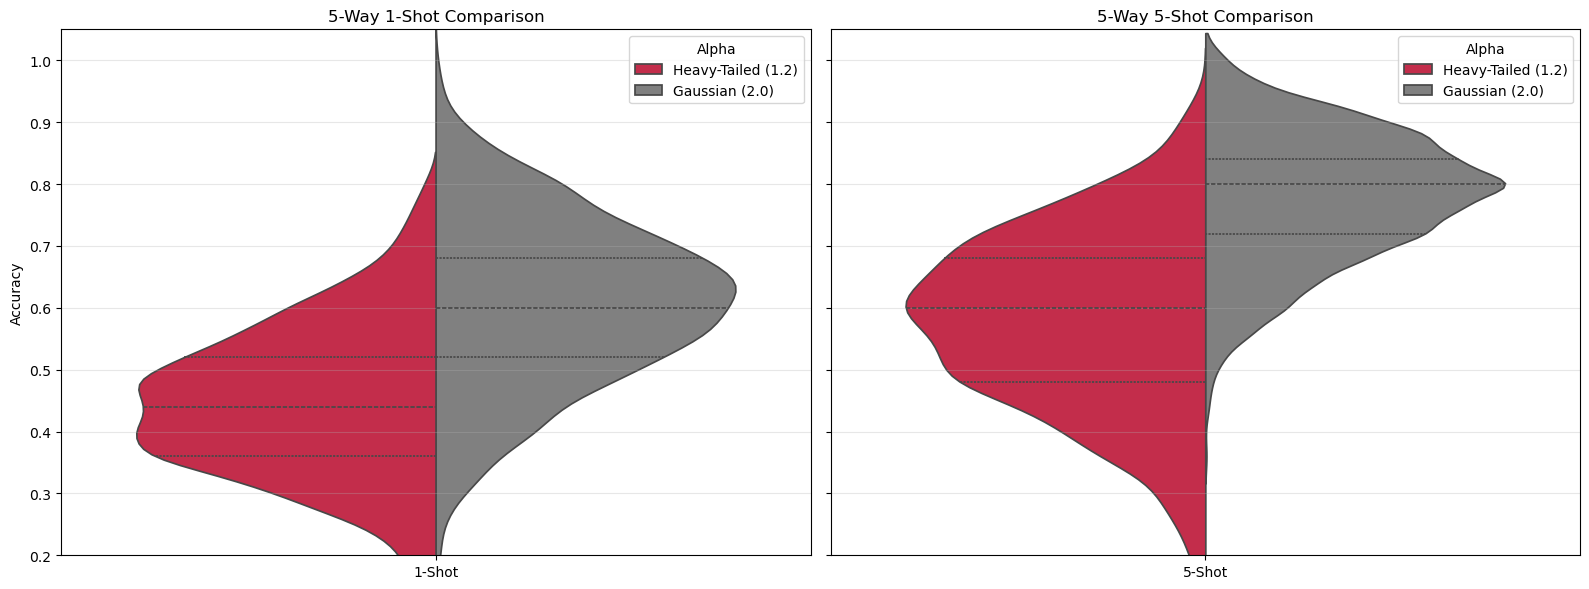

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import skew, kurtosis

def get_summary_stats(group):
    """Calculates detailed metrics for each distribution."""
    data = group['Accuracy']
    mean = data.mean()
    std = data.std()
    count = len(data)

    # 95% Confidence Interval
    ci95_hi = mean + 1.96 * (std / (count**0.5))
    ci95_lo = mean - 1.96 * (std / (count**0.5))

    return pd.Series({
        'Mean': mean,
        'Median': data.median(),
        'Std Dev': std,
        'Skewness': skew(data),
        'Kurtosis': kurtosis(data),
        'Q1 (25%)': data.quantile(0.25),
        'Q3 (75%)': data.quantile(0.75),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        '95% CI Lower': ci95_lo,
        '95% CI Upper': ci95_hi
    })

# Updated paths to match your new output root
root_dir = Path('/home/yihao/honours/few_shot_results/mlp_cos_eval')
output_plots = 'few_shot_comparison_mlp_cos_eval.png'

data_list = []

# Iterate through the Experiment Type folders (HT vs Gaussian)
for experiment_folder in root_dir.iterdir():
    if not experiment_folder.is_dir():
        continue

    # Determine Init Type from the parent folder name
    if "HT_alpha_1.2" in experiment_folder.name:
        init_type = 'Heavy-Tailed (1.2)'
    elif "Gaussian" in experiment_folder.name:
        init_type = 'Gaussian (2.0)'
    else:
        continue

    # Walk through each seed/timestamp folder within the experiment type
    for run_folder in experiment_folder.iterdir():
        if not run_folder.is_dir():
            continue

        # Extract seed from folder name (e.g., GeneralMLP_..._s0)
        try:
            seed = run_folder.name.split('_s')[-1]
        except IndexError:
            seed = "unknown"

        # Load 1-shot and 5-shot data
        for shot_type in ['1shot', '5shot']:
            file_path = run_folder / f'fs_{shot_type}_raw.csv'

            if file_path.exists():
                # Load raw episode accuracies (one per row)
                accs = pd.read_csv(file_path, header=None).squeeze()

                temp_df = pd.DataFrame({
                    'Accuracy': accs,
                    'Alpha': init_type,
                    'Shot': shot_type.replace('shot', '-Shot'),
                    'Seed': seed
                })
                data_list.append(temp_df)

if not data_list:
    print("No data found! Check your root_dir and folder structure.")
else:
    # Combine everything
    df = pd.concat(data_list, ignore_index=True)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for i, shot in enumerate(['1-Shot', '5-Shot']):
        sns.violinplot(
            data=df[df['Shot'] == shot],
            x='Shot',              # Use Shot as the x-axis or a dummy variable
            y='Accuracy',
            hue='Alpha',           # Split based on your Alpha labels
            split=True,            # Enable the face-to-face split
            inner='quartile',      # Keep quartile lines for statistical depth
            palette={'Heavy-Tailed (1.2)': 'crimson', 'Gaussian (2.0)': 'gray'},
            ax=axes[i]
        )
        axes[i].set_title(f'5-Way {shot} Comparison')
        axes[i].set_ylim(0.2, 1.05)
        axes[i].grid(axis='y', alpha=0.3)
        # Clean up x-label if it's redundant
        axes[i].set_xlabel('')

    plt.tight_layout()
    plt.savefig(output_plots)
    print(f'Plots saved to {output_plots}')

    # Compute stats
    full_stats = df.groupby(['Shot', 'Alpha']).apply(get_summary_stats, include_groups=False).reset_index()

    print("\n" + "="*80)
    print("DETAILED FEW-SHOT REPRESENTATION ANALYSIS")
    print("="*80)

    for shot in ['1-Shot', '5-Shot']:
        print(f"\n>>> Results for {shot}:")
        subset = full_stats[full_stats['Shot'] == shot].set_index('Alpha')
        print(subset.drop(columns='Shot').T)

        # Calculate Delta
        try:
            g_mean = subset.loc['Gaussian (2.0)', 'Mean']
            h_mean = subset.loc['Heavy-Tailed (1.2)', 'Mean']
            improvement = ((h_mean - g_mean) / g_mean) * 100
            print(f"\nRelative Improvement (Heavy vs Gaussian): {improvement:.2f}%")
        except KeyError:
            print("\nMissing one of the groups (HT or Gaussian) to calculate delta.")

    print("\n" + "="*80)

Generalization plots saved to generalization_curves_mlp_cos_eval.png


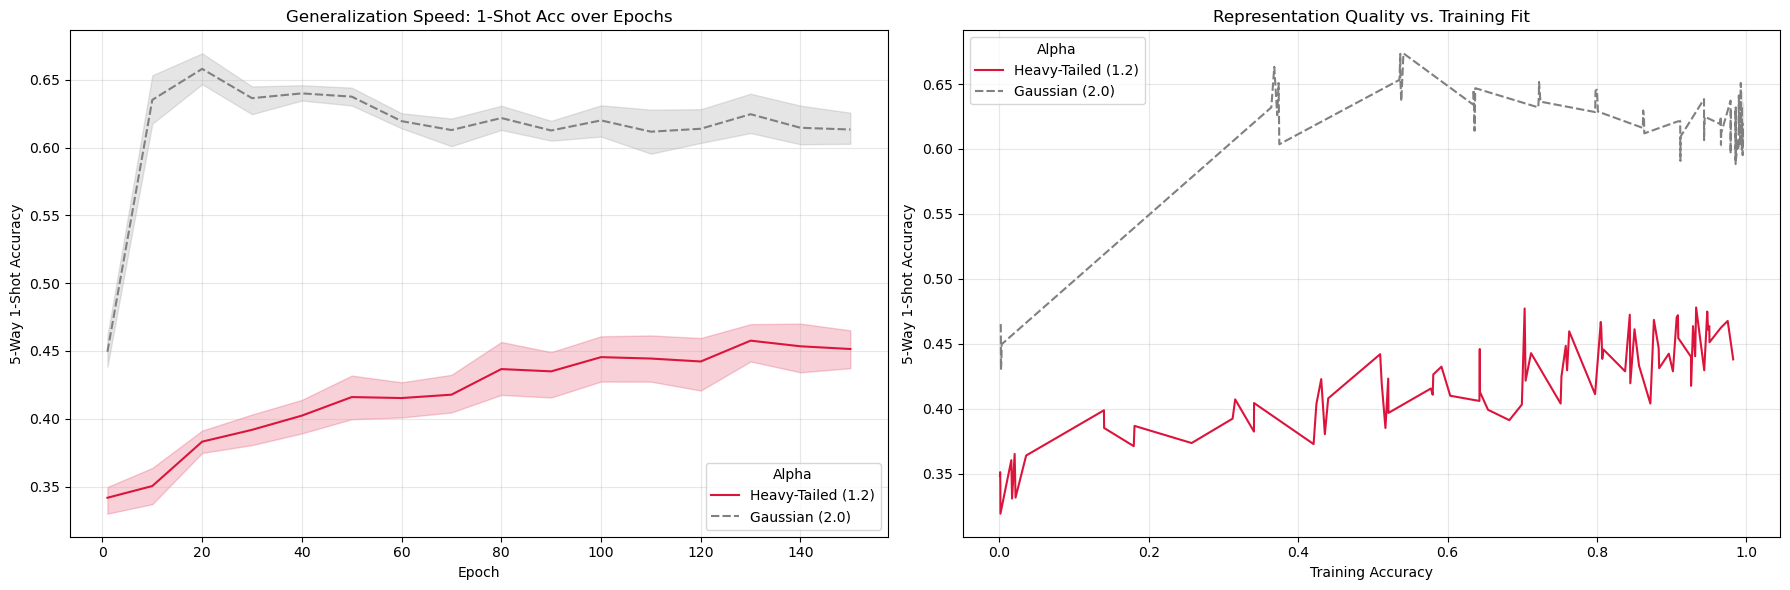

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Updated root directory for the new result structure
root_dir = Path('/home/yihao/honours/few_shot_results/mlp_cos_eval')
output_plot = 'generalization_curves_mlp_cos_eval.png'

all_logs = []

# Iterate through experiment type folders
for experiment_folder in root_dir.iterdir():
    if not experiment_folder.is_dir():
        continue

    # Resolve initialization label from the parent folder name
    if 'HT_alpha_1.2' in experiment_folder.name:
        init_type = 'Heavy-Tailed (1.2)'
    elif 'Gaussian' in experiment_folder.name:
        init_type = 'Gaussian (2.0)'
    else:
        continue

    # Process each individual run folder
    for run_folder in experiment_folder.iterdir():
        if not run_folder.is_dir():
            continue

        # Extract seed from the suffix (e.g., _s0)
        seed = run_folder.name.split('_s')[-1]

        # Look for the consolidated training log
        log_file = run_folder / 'train_log.csv'

        if log_file.exists():
            log_df = pd.read_csv(log_file)

            # Attach metadata for plotting
            log_df['Alpha'] = init_type
            log_df['Seed'] = seed
            all_logs.append(log_df)

if not all_logs:
    print('No training logs found.')
else:
    combined_df = pd.concat(all_logs, ignore_index=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot 1: Generalization Speed
    sns.lineplot(
        data=combined_df,
        x='epoch',
        y='fs_1shot_mean',
        hue='Alpha',
        style='Alpha',
        palette={'Heavy-Tailed (1.2)': 'crimson', 'Gaussian (2.0)': 'gray'},
        ax=ax1
    )
    ax1.set_title('Generalization Speed: 1-Shot Acc over Epochs')
    ax1.set_ylabel('5-Way 1-Shot Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.grid(True, alpha=0.3)

    # Plot 2: Generalization Gap
    sns.lineplot(
        data=combined_df,
        x='train_acc',
        y='fs_1shot_mean',
        hue='Alpha',
        style='Alpha',
        palette={'Heavy-Tailed (1.2)': 'crimson', 'Gaussian (2.0)': 'gray'},
        ax=ax2
    )
    ax2.set_title('Representation Quality vs. Training Fit')
    ax2.set_ylabel('5-Way 1-Shot Accuracy')
    ax2.set_xlabel('Training Accuracy')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(output_plot)
    print(f'Generalization plots saved to {output_plot}')

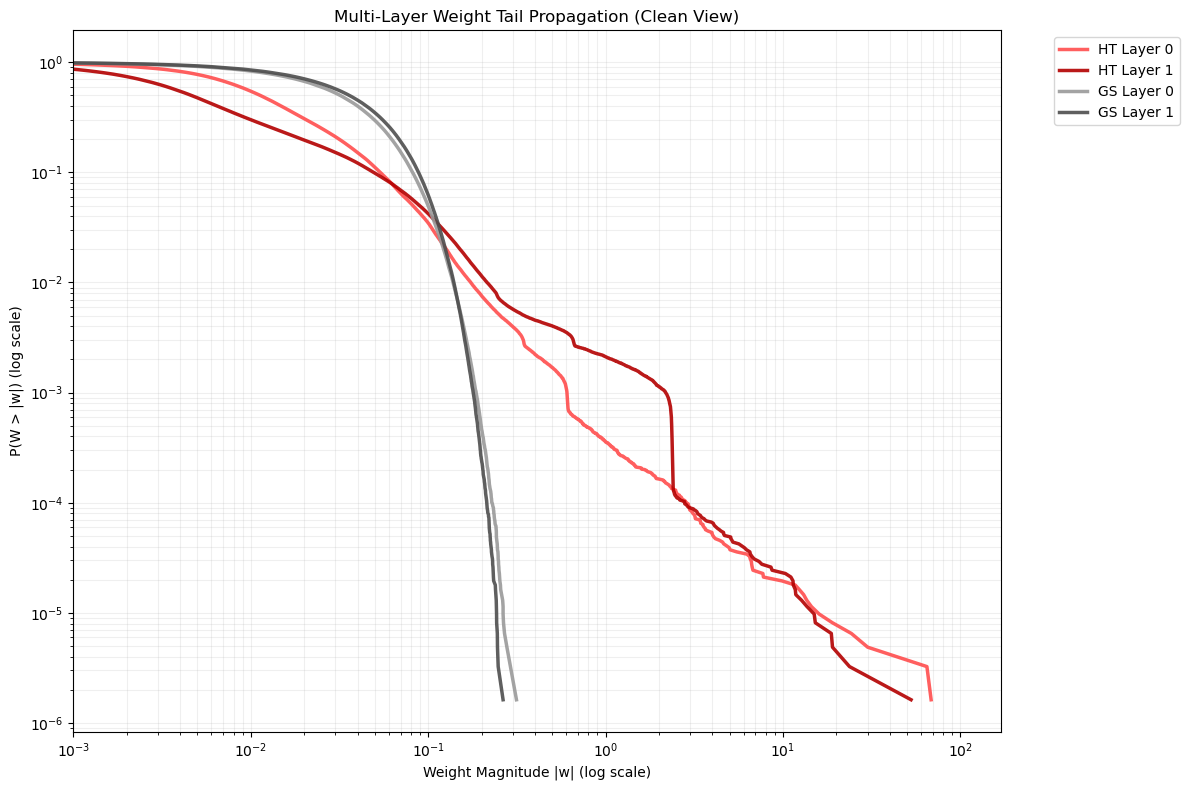

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_combined_tails_clean(root_path):
    root_dir = Path(root_path)
    plt.figure(figsize=(12, 8))

    # 1. High-contrast, darker sequential palettes
    # HT: Crimson to Deep Maroon | GS: Slate to Jet Black
    ht_palette = ['#ff4d4d', '#b30000', '#4d0000']
    gs_palette = ['#999999', '#4d4d4d', '#000000']

    all_data = {}

    # --- Data Collection ---
    for experiment_folder in root_dir.iterdir():
        if not experiment_folder.is_dir(): continue
        label = 'HT' if 'HT_alpha_1.2' in experiment_folder.name else 'GS'
        all_data[label] = {}

        for run_folder in experiment_folder.iterdir():
            checkpoint = run_folder / 'final_model.pth'
            if not checkpoint.exists(): continue

            # Use only seed 0 for the combined clear view
            if '_s0' not in run_folder.name: continue

            state_dict = torch.load(checkpoint, map_location='cpu')['model_state']
            conv_keys = sorted([k for k in state_dict.keys() if 'weight' in k and 'features' in k])

            for l_idx, layer_key in enumerate(conv_keys):
                w = state_dict[layer_key].numpy().flatten()
                w_abs = np.abs(w[np.abs(w) > 1e-6])

                sorted_w = np.sort(w_abs)
                ccdf = 1.0 - np.arange(len(sorted_w)) / float(len(sorted_w))
                all_data[label][l_idx] = (sorted_w, ccdf)

    # --- Plotting ---
    for label, layers in all_data.items():
        palette = ht_palette if label == 'HT' else gs_palette

        for l_idx, (sorted_w, ccdf) in layers.items():
            color = palette[min(l_idx, len(palette)-1)]

            # Clean lines without shading for maximum slope clarity
            plt.plot(sorted_w, ccdf,
                     label=f'{label} Layer {l_idx}',
                     color=color,
                     lw=2.5,
                     alpha=0.9)

    plt.xscale('log')
    plt.xlim(1e-3)
    plt.yscale('log')
    plt.xlabel('Weight Magnitude |w| (log scale)')
    plt.ylabel('P(W > |w|) (log scale)')
    plt.title('Multi-Layer Weight Tail Propagation (Clean View)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', ls='-', alpha=0.2)
    plt.tight_layout()
    plt.savefig('combined_layer_tails.png')
    plt.show()

plot_combined_tails_clean('/home/yihao/honours/few_shot_results/mlp')

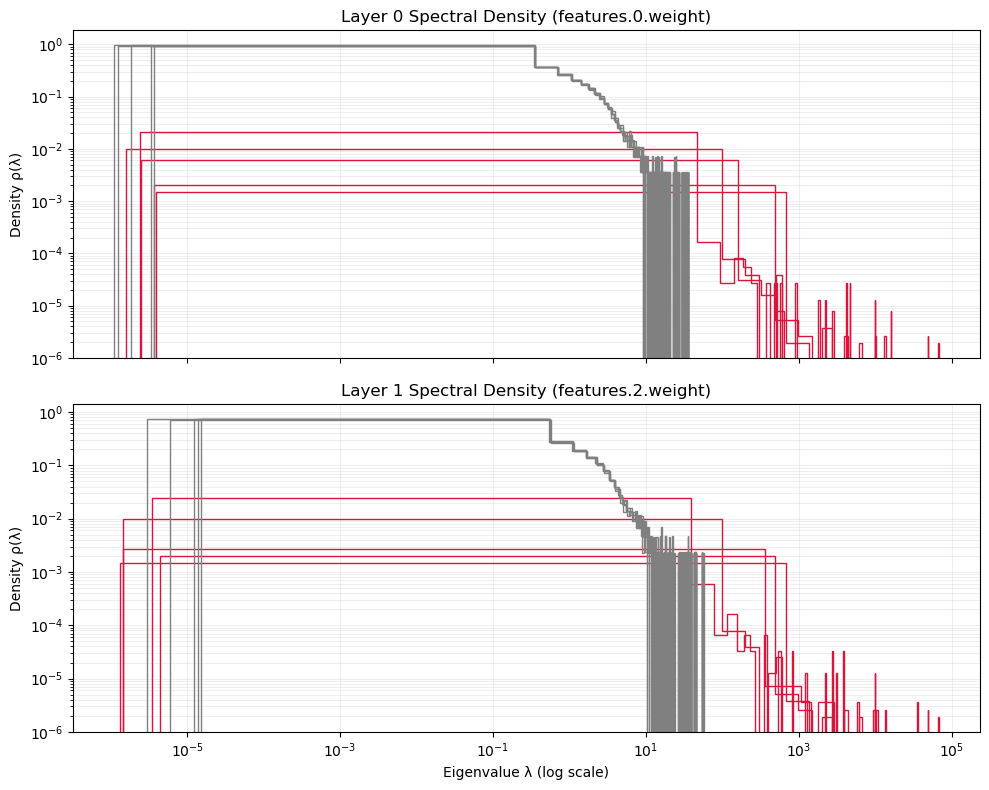

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_multi_layer_esd(root_path):
    root_dir = Path(root_path)

    # Identify layers first to set up the grid
    # We'll use one seed to determine the layer structure
    sample_run = next(root_dir.glob('**/final_model.pth'))
    sample_state = torch.load(sample_run, map_location='cpu')['model_state']
    conv_keys = sorted([k for k in sample_state.keys() if 'weight' in k and 'features' in k])
    num_layers = len(conv_keys)

    fig, axes = plt.subplots(num_layers, 1, figsize=(10, 4 * num_layers), sharex=True)
    if num_layers == 1: axes = [axes]

    # --- Data Collection and Plotting ---
    for experiment_folder in root_dir.iterdir():
        if not experiment_folder.is_dir(): continue

        is_ht = 'HT_alpha_1.2' in experiment_folder.name
        color = 'crimson' if is_ht else 'gray'
        label_prefix = 'HT (1.2)' if is_ht else 'GS (2.0)'

        for run_folder in experiment_folder.iterdir():
            checkpoint = run_folder / 'final_model.pth'
            if not checkpoint.exists(): continue

            # Use all seeds but keep alpha low to see the 'Expected' distribution
            seed = run_folder.name.split('_s')[-1]
            state_dict = torch.load(checkpoint, map_location='cpu')['model_state']

            for l_idx, layer_key in enumerate(conv_keys):
                W = state_dict[layer_key]

                # Flatten Conv2d to 2D matrix for spectral analysis
                if W.dim() == 4:
                    W = W.view(W.size(0), -1)

                # Compute X = W^T * W (or vice versa for efficiency)
                if W.shape[0] > W.shape[1]:
                    X = torch.matmul(W.t(), W)
                else:
                    X = torch.matmul(W, W.t())

                evals = torch.linalg.eigvalsh(X).numpy()
                evals = evals[evals > 1e-6] # Filter noise

                # Plot on the specific subplot for this depth
                axes[l_idx].hist(evals, bins=100, density=True, histtype='step',
                                 color=color, alpha=1.0, label=f"{label_prefix} s{seed}")

                if seed == '0': # Set titles only once
                    axes[l_idx].set_title(f'Layer {l_idx} Spectral Density ({layer_key})')
                    axes[l_idx].set_yscale('log')
                    axes[l_idx].set_xscale('log')

    for ax in axes:
        ax.grid(True, which='both', alpha=0.2)
        ax.set_ylabel('Density ρ(λ)')

    axes[-1].set_xlabel('Eigenvalue λ (log scale)')
    plt.tight_layout()
    plt.savefig('multi_layer_esd_grid.png')
    plt.show()

plot_multi_layer_esd('/home/yihao/honours/few_shot_results/mlp')

/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/yihao/miniconda3/envs/honours/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


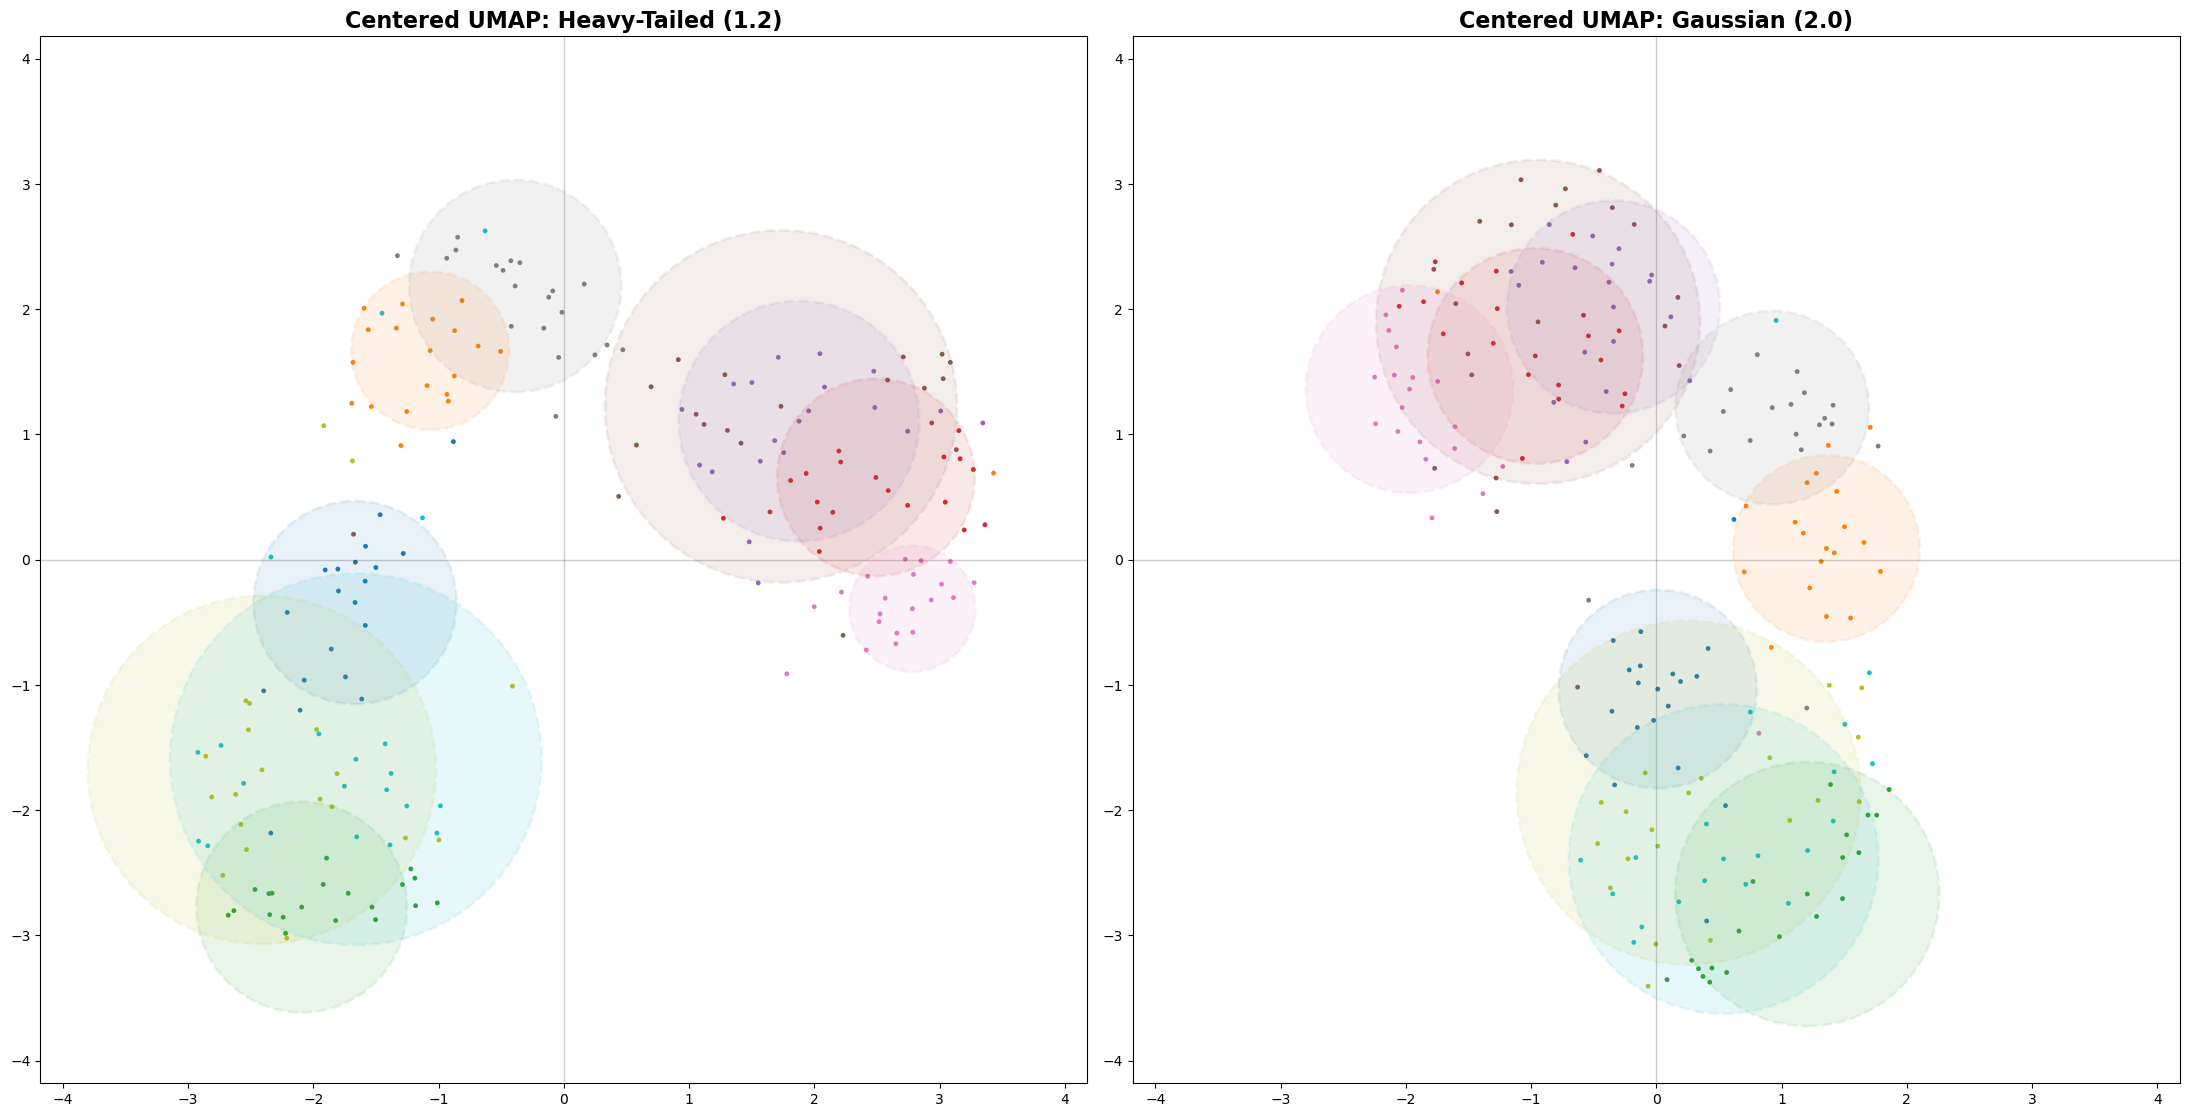

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.datasets import Omniglot
from scipy.spatial.distance import cdist
# Import your model classes
from src import ResearchCNN, GeneralMLP

def extract_embeddings(model, dataloader, device):
    """Passes data through the model to get the HT feature vectors."""
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            # Use your custom feature extractor logic
            out = model.get_features(imgs)
            features.append(out.cpu().numpy())
            labels.append(lbls.numpy())

    return np.concatenate(features), np.concatenate(labels)

def plot_hybrid_bubbles(ax, points, color, label_idx, p_threshold=0.80):
    """Draws raw points with a superimposed density bubble."""
    # 1. Plot the raw points first (low alpha to keep them as background)
    ax.scatter(points[:, 0], points[:, 1], color=color, s=12, alpha=1.0,
               edgecolors='none', zorder=2)

    # 2. Find the Medoid (Geometric Center)
    dists = cdist(points, points, metric='euclidean')
    medoid_idx = np.argmin(dists.sum(axis=1))
    medoid = points[medoid_idx]

    # 3. Calculate Radius for the Core
    dists_to_medoid = np.linalg.norm(points - medoid, axis=1)
    radius = np.percentile(dists_to_medoid, p_threshold * 100)

    # 4. Draw the Bubble (Very light fill, solid edge)
    circle = plt.Circle(medoid, radius, color=color, alpha=0.1,
                        ec=color, lw=2, linestyle='--', zorder=3)
    ax.add_patch(circle)

    # 5. Add a small label for the class
    # ax.text(medoid[0], medoid[1], str(label_idx), fontsize=9,
    #         fontweight='bold', ha='center', va='center',
    #         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1),
    #         zorder=4)

def run_umap_analysis(root_path, test_dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    root_dir = Path(root_path)
    num_viz_classes = 10

    ht_path = next(root_dir.glob('HT_alpha_1.2/**/final_model.pth'))
    gs_path = next(root_dir.glob('Gaussian_Baseline/**/final_model.pth'))
    paths = [('Heavy-Tailed (1.2)', ht_path), ('Gaussian (2.0)', gs_path)]

    # Store embeddings to calculate global limits
    all_embeddings = []
    plot_data = []

    for label, p in paths:
        # model = ResearchCNN(input_channels=1, base_channels=32, num_classes=964, depth=3).to(device)
        model = GeneralMLP(input_size=784, hidden_size=784, num_classes=964, depth=2, bias=False).to(device)
        model.load_state_dict(torch.load(p, map_location=device)['model_state'])

        feats, lbls = extract_embeddings(model, loader, device)
        mask = lbls < num_viz_classes

        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)
        embedding = reducer.fit_transform(feats[mask])

        all_embeddings.append(embedding)
        plot_data.append((label, embedding, lbls[mask]))

    # 1. Centering and Global Bounds Calculation
    centered_plot_data = []
    global_max_abs = 0

    for label, emb, lbls in plot_data:
        # Calculate the translation vector (centroid)
        centroid = emb.mean(axis=0)
        # Shift embedding to (0,0)
        centered_emb = emb - centroid

        # Update global bounds for a perfectly symmetric square view
        current_max = np.abs(centered_emb).max()
        if current_max > global_max_abs:
            global_max_abs = current_max

        centered_plot_data.append((label, centered_emb, lbls))

    # 2. Final Plotting
    fig, axes = plt.subplots(1, 2, figsize=(22, 11))
    # Add a buffer to the limits so bubbles aren't clipped
    limit = global_max_abs + 0.75

    for i, (label, embedding, current_lbls) in enumerate(centered_plot_data):
        unique_labels = np.unique(current_lbls)
        palette = sns.color_palette("tab10", n_colors=len(unique_labels))

        for idx, cl in enumerate(unique_labels):
            class_points = embedding[current_lbls == cl]
            plot_hybrid_bubbles(axes[i], class_points, palette[idx], int(cl))

        # Standardize formatting
        axes[i].set_aspect('equal')
        axes[i].set_xlim(-limit, limit)
        axes[i].set_ylim(-limit, limit)

        # Add a zero-line crosshair for visual centering reference
        axes[i].axhline(0, color='black', lw=1, alpha=0.2)
        axes[i].axvline(0, color='black', lw=1, alpha=0.2)

        axes[i].set_title(f"Centered UMAP: {label}", fontsize=16, fontweight='bold')

    # plt.suptitle("Comparative Embedding Topology (Centered & Standardized)", fontsize=20)
    plt.tight_layout()
    plt.savefig('umap_projection.png')
    plt.show()

# Execution
# Ensure Omniglot is downloaded and transformed to 28x28
transform = transforms.Compose([transforms.Resize((28, 28)), transforms.ToTensor()])
omniglot_test = Omniglot(root='./data', background=False, download=True, transform=transform)

run_umap_analysis('/home/yihao/honours/few_shot_results/mlp', omniglot_test)